# User clustering — personas

Group users into a few *personas* by the kind of movies they like: genres and production style (budget scale, box-office success, era, runtime, director / cast track record, country). 
- Does the production metadata add to a clustering on genres alone?
- Does adding a taste for polarizing movies (movie `rating_std`) improve the clustering?

Both questions are answered here by comparing three clusterings (section 4).

Inputs come from `06_split_and_user_eda.ipynb` and use **training movies only**, so the personas carry no information about validation / test movies. 

Generosity (`user_mean`, `user_std`, number of ratings) is deliberately **not** a clustering feature: it would split users into generous vs. harsh raters instead of by taste. It enters the model directly in `08`.

## 1. Load

Eligible users (≥ 20 ratings of training movies) and their ratings of training movies.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

PROCESSED = Path("../data/processed")
RANDOM_STATE = 42

movies = pd.read_csv(PROCESSED / "movies_features.csv", usecols=lambda c: c not in {"director", "cast_top5"})
movies = (
    movies.merge(pd.read_csv(PROCESSED / "movie_split.csv"), on="netflix_movie_id")
    .merge(pd.read_csv(PROCESSED / "track_records.csv"), on="netflix_movie_id")
    .merge(pd.read_csv(PROCESSED / "movie_stats_train.csv")[["netflix_movie_id", "rating_std"]], on="netflix_movie_id", how="left")
)
train_movies = movies[movies["split"] == "train"].set_index("netflix_movie_id")
user_stats = pd.read_csv(PROCESSED / "user_stats_train.csv").set_index("rater_id")

chunks = pd.read_csv(
    PROCESSED / "ratings.csv",
    usecols=["netflix_movie_id", "rater_id", "rating"],
    dtype={"netflix_movie_id": "int32", "rater_id": "int32", "rating": "int8"},
    chunksize=5_000_000,
)
ratings = pd.concat(
    c[c["netflix_movie_id"].isin(train_movies.index) & c["rater_id"].isin(user_stats.index)] for c in chunks
).reset_index(drop=True)

print(f"training movies: {len(train_movies)} | eligible users: {len(user_stats):,} | ratings: {len(ratings):,}")

c:\Users\yael\anaconda3\envs\pythonProject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


training movies: 919 | eligible users: 332,632 | ratings: 34,243,173


## 2. Movie profile features

The movie properties a user's taste is described by:
- **genres** (18 multi-hot columns),
- **production:** `runtime`, `movie_age_log`, `budget_log`, `log_roi` (box-office success relative to cost), `director_track_record`, `cast_track_record`, `non_us`,
- **polarization:** `rating_std` of the movie on training ratings.

`budget_log` and `log_roi` are correlated (taste profiles: r ≈ −0.48) but describe different tastes: big productions vs. commercial hits.

`lang_en` is not used. 98% of training movies are in English, so the column is almost constant and a user's taste for it rests on a handful of films. It also repeats `non_us` (r ≈ −0.5 between the two taste profiles). After standardization every column weighs the same in the K-Means distance, so a noisy duplicate would get as much weight as a genre.

In [2]:
GENRE_COLS = [c for c in movies.columns if c.startswith("genre_")]
PRODUCTION_COLS = [
    "runtime",
    "movie_age_log",
    "budget_log",
    "log_roi",
    "director_track_record",
    "cast_track_record",
    "non_us",
]
STD_COL = "rating_std"
PROFILE_COLS = GENRE_COLS + PRODUCTION_COLS + [STD_COL]

movie_feat = train_movies[PROFILE_COLS]
assert movie_feat.notna().all().all()

In [3]:
movie_feat.head()

,genre_action,genre_adventure,genre_animation,genre_comedy,genre_crime,genre_documentary,genre_drama,genre_family,genre_fantasy,genre_history,...,genre_war,genre_western,runtime,movie_age_log,budget_log,log_roi,director_track_record,cast_track_record,non_us,rating_std
netflix_movie_id,,,,,,,,,,,,,,,,,,,,,
30,0,0,0,1,0,0,1,0,0,0,...,0,0,128.0,1.098612,18.197537,1.204206,3.441413,3.418507,0,0.938613
58,0,0,0,0,0,0,0,0,1,0,...,0,0,103.0,2.302585,17.858562,0.704203,3.365359,3.515183,0,0.952260
78,0,0,0,1,0,0,0,1,0,0,...,0,0,89.0,2.302585,17.909855,0.771900,3.426826,3.375336,0,1.138207
143,0,0,0,0,0,0,1,0,0,0,...,0,0,129.0,2.197225,17.727534,0.783204,3.588609,3.481134,0,0.921834
148,0,0,0,0,0,0,1,0,0,0,...,0,0,119.0,1.609438,17.504390,0.497045,3.441413,3.481255,0,1.076310


## 3. User taste profiles

For each user, every rated movie is weighted by how much the user liked it **relative to their own average**: `w = rating − user_mean` (positive = liked more than usual, negative = liked less). The profile is the weighted average of the movie features:

$$\text{profile}_u = \frac{\sum_i w_{ui}\, x_i}{\sum_i |w_{ui}|}$$

- Because the weights of a user sum to zero, a user who rates everything the same gets no taste, and generosity is removed by construction.
- For a genre column the value is positive when the user rates that genre above their own average, negative when below.
- For a numeric column (e.g. `runtime`) the value is positive when the user prefers movies with higher values (longer films), independent of the average level of the column.

The weights form a sparse user × movie matrix, so all profiles are one matrix product. Users with all-equal ratings (Σ|w| = 0) have no profile and are dropped.

In [4]:
user_index = pd.Index(user_stats.index)
movie_index = pd.Index(movie_feat.index)
rows = user_index.get_indexer(ratings["rater_id"])
cols = movie_index.get_indexer(ratings["netflix_movie_id"])
w = ratings["rating"].to_numpy(dtype=float) - user_stats["user_mean"].to_numpy()[rows]

W = sparse.csr_matrix((w, (rows, cols)), shape=(len(user_index), len(movie_index)))
abs_w = np.asarray(abs(W).sum(axis=1)).ravel()
has_taste = abs_w > 0

profiles = pd.DataFrame(
    (W[has_taste] @ movie_feat.to_numpy()) / abs_w[has_taste, None],
    index=user_index[has_taste],
    columns=PROFILE_COLS,
)
profiles.index.name = "rater_id"
print(f"profiles: {profiles.shape} (dropped {int((~has_taste).sum())} users with all-equal ratings)")
# profiles.describe().T.round(3)

profiles: (332265, 26) (dropped 367 users with all-equal ratings)


Checking correlations between profile features. A strongly correlated pair describes the same taste twice and counts twice in the K-Means distance. The strongest pairs are moderate (history–war ≈ 0.7, action–adventure and action–budget ≈ 0.55), so all of these features are kept.

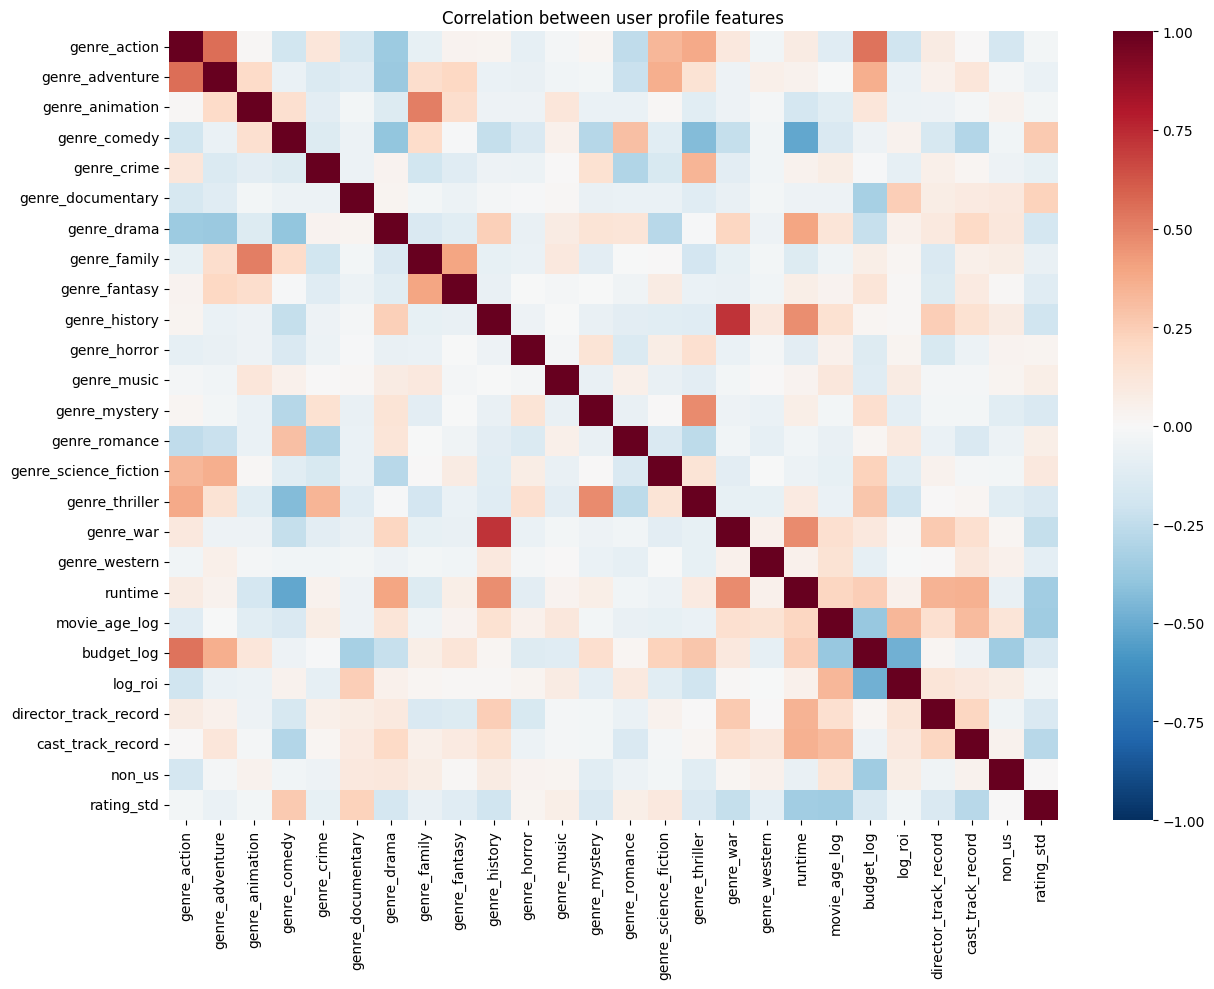

In [5]:
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(profiles.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Correlation between user profile features")
fig.tight_layout()
plt.show()

## 4. Clustering

The same users are clustered on three feature sets:

| variant | features | question |
|---|---|---|
| **genre_only** | 18 genres | baseline |
| **genre_production** | genres + 7 production features | does production style add to genre taste? |
| **genre_production_std** | genres + production + `rating_std` | does polarization taste improve the clustering? |

Pipeline for each: StandardScaler → K-Means.

For k = 2…10 the plots show the **silhouette** (how well separated the clusters are; computed on a 20k-user sample because it is quadratic in the number of users) and the **inertia** (elbow).
- **Inertia** grows with the number of features (after standardization each feature adds ~1 unit of variance per user), so it is shown as a share of the inertia at k = 1, i.e. of the total variance `n_users × n_features`. The y-axis then reads as *the share of taste variance not explained by the personas*, and the three variants share one scale.
- **Silhouette** needs no rescaling: it is already a ratio between −1 and 1. Silhouette values are compared *within* a variant: each feature set defines its own distance, so they are not comparable between variants (with more features, distances become more alike, which lowers the silhouette by itself).

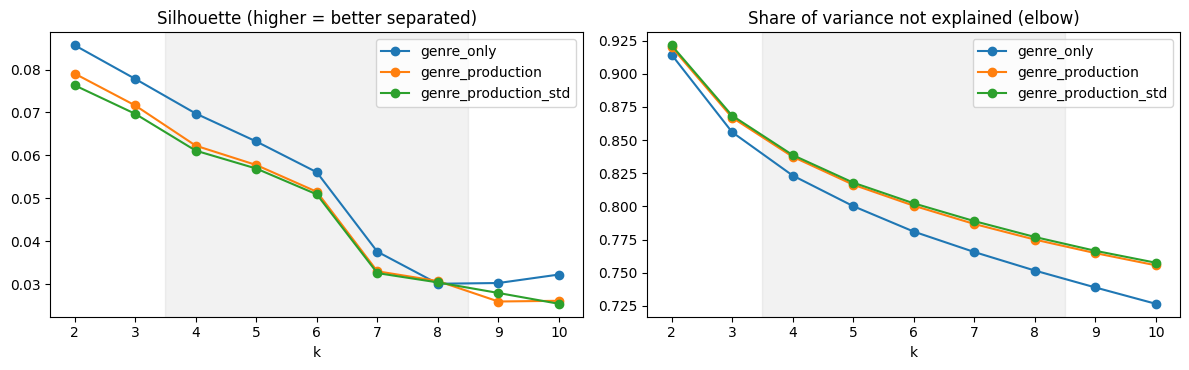

genre_only                                genre_production               \
   silhouette      inertia unexplained share       silhouette      inertia   
k                                                                            
2       0.086  5469134.055             0.914            0.079  7643805.881   
3       0.078  5119779.570             0.856            0.072  7202113.002   
4       0.070  4924183.278             0.823            0.062  6956717.202   
5       0.063  4786248.276             0.800            0.058  6781810.327   
6       0.056  4671462.846             0.781            0.052  6650111.622   
7       0.038  4579395.293             0.766            0.033  6535814.457   
8       0.030  4495912.690             0.752            0.031  6438108.701   
9       0.030  4419619.065             0.739            0.026  6353360.020   
10      0.032  4345901.810             0.727            0.026  6276888.431   

                     genre_production_std                                 
   unexplained share           silhouette      inertia unexplained share  
k                                                                         
2              0.920                0.076  7960700.049             0.921  
3              0.867                0.070  7502602.265             0.868  
4              0.837                0.061  7246077.871             0.839  
5              0.816                0.057  7066463.163             0.818  
6              0.801                0.051  6931579.405             0.802  
7              0.787                0.033  6815902.870             0.789  
8              0.775                0.030  6712564.065             0.777  
9              0.765                0.028  6622528.466             0.767  
10             0.756                0.025  6544811.322             0.758

In [6]:
VARIANTS = {
    "genre_only": GENRE_COLS,
    "genre_production": GENRE_COLS + PRODUCTION_COLS,
    "genre_production_std": GENRE_COLS + PRODUCTION_COLS + [STD_COL],
}
K_SWEEP = list(range(2, 11))
K_RANGE = range(4, 9)
SIL_SAMPLE = 20_000

rng = np.random.default_rng(RANDOM_STATE)
sil_idx = rng.choice(len(profiles), size=SIL_SAMPLE, replace=False)

prep, sweep = {}, {}
for name, cols in VARIANTS.items():
    scaler = StandardScaler().fit(profiles[cols])
    X = scaler.transform(profiles[cols])
    prep[name] = {"cols": cols, "scaler": scaler, "X": X}
    rows = []
    for k in K_SWEEP:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
        rows.append({"k": k, "silhouette": silhouette_score(X[sil_idx], km.labels_[sil_idx]), "inertia": km.inertia_})
    sweep[name] = pd.DataFrame(rows).set_index("k")
    # inertia at k = 1 = total variance of the standardized features = n_users * n_features
    sweep[name]["unexplained share"] = sweep[name]["inertia"] / X.size

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for name, res in sweep.items():
    axes[0].plot(res.index, res["silhouette"], marker="o", label=name)
    axes[1].plot(res.index, res["unexplained share"], marker="o", label=name)
for ax, title in zip(axes, ["Silhouette (higher = better separated)", "Share of variance not explained (elbow)"]):
    ax.axvspan(min(K_RANGE) - 0.5, max(K_RANGE) + 0.5, color="gray", alpha=0.1)
    ax.set_xlabel("k")
    ax.set_title(title)
    ax.legend()
fig.tight_layout()
plt.show()
pd.concat(sweep, axis=1).round(3)

Taste profiles form a continuum rather than well-separated groups, so silhouettes are expected to be low; k is chosen in 4–8, the range where personas are still few enough to describe. 

**Stability.** A persona is only meaningful if it reappears when the data changes a little. For each k in the range, K-Means is fitted on two random halves of the users and both models label all users; the adjusted Rand index (ARI) between the two labelings is 1 for identical personas and ~0 for unrelated ones.

In [7]:
def stability(X, k, seed=RANDOM_STATE):
    idx = np.random.default_rng(seed).permutation(len(X))
    half_a, half_b = idx[: len(X) // 2], idx[len(X) // 2 :]
    km_a = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X[half_a])
    km_b = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X[half_b])
    return adjusted_rand_score(km_a.predict(X), km_b.predict(X))


stab = pd.DataFrame(
    {name: {k: stability(prep[name]["X"], k) for k in K_RANGE} for name in VARIANTS}
).rename_axis("k")
stab.round(3)

,genre_only,genre_production,genre_production_std
k,,,
4,0.971,0.939,0.942
5,0.930,0.913,0.907
6,0.917,0.911,0.726
7,0.508,0.909,0.899
8,0.879,0.532,0.824


`BEST_K` is chosen from the silhouette, elbow and stability above. All three variants are fitted with the same k so their personas can be compared side by side. The ARI between two variants shows how much the added features change the grouping of users (1 = same personas).

In [8]:
BEST_K = 5

fits = {name: KMeans(n_clusters=BEST_K, n_init=10, random_state=RANDOM_STATE).fit(prep[name]["X"]) for name in VARIANTS}
display(pd.DataFrame({
    name: {
        "silhouette": silhouette_score(prep[name]["X"][sil_idx], km.labels_[sil_idx]),
        "stability (ARI)": stab.loc[BEST_K, name],
        "smallest persona (% users)": 100 * np.bincount(km.labels_).min() / len(km.labels_),
    }
    for name, km in fits.items()
}).T.round(3))

pairs = [("genre_only", "genre_production"), ("genre_production", "genre_production_std")]
print("ARI results:")
pd.Series(
    {f"{a} vs {b}": adjusted_rand_score(fits[a].labels_, fits[b].labels_) for a, b in pairs},
    name="agreement (ARI)",
).round(3)

,silhouette,stability (ARI),smallest persona (% users)
genre_only,0.063,0.930,15.172
genre_production,0.058,0.913,16.893
genre_production_std,0.057,0.907,17.224


ARI results:


genre_only vs genre_production              0.280
genre_production vs genre_production_std    0.798
Name: agreement (ARI), dtype: float64

**Comparing the personas of the three variants.** One heatmap per variant: each row is a persona, each column a profile feature, and the colour is the persona's average standardized taste (0 = average user, ±1 = one standard deviation more / less taste for that feature). Columns a variant does not use are left blank, so the same feature sits in the same position in all three panels.

- If production style adds something, the genre_production personas differ from the genre_only ones in their production columns (budget, ROI, era, country), not only in their genres.
- If polarization taste helps, the `rating_std` column of the third panel separates personas clearly, without lowering stability.

The persona numbers are arbitrary in each variant: compare the profiles, not the labels.

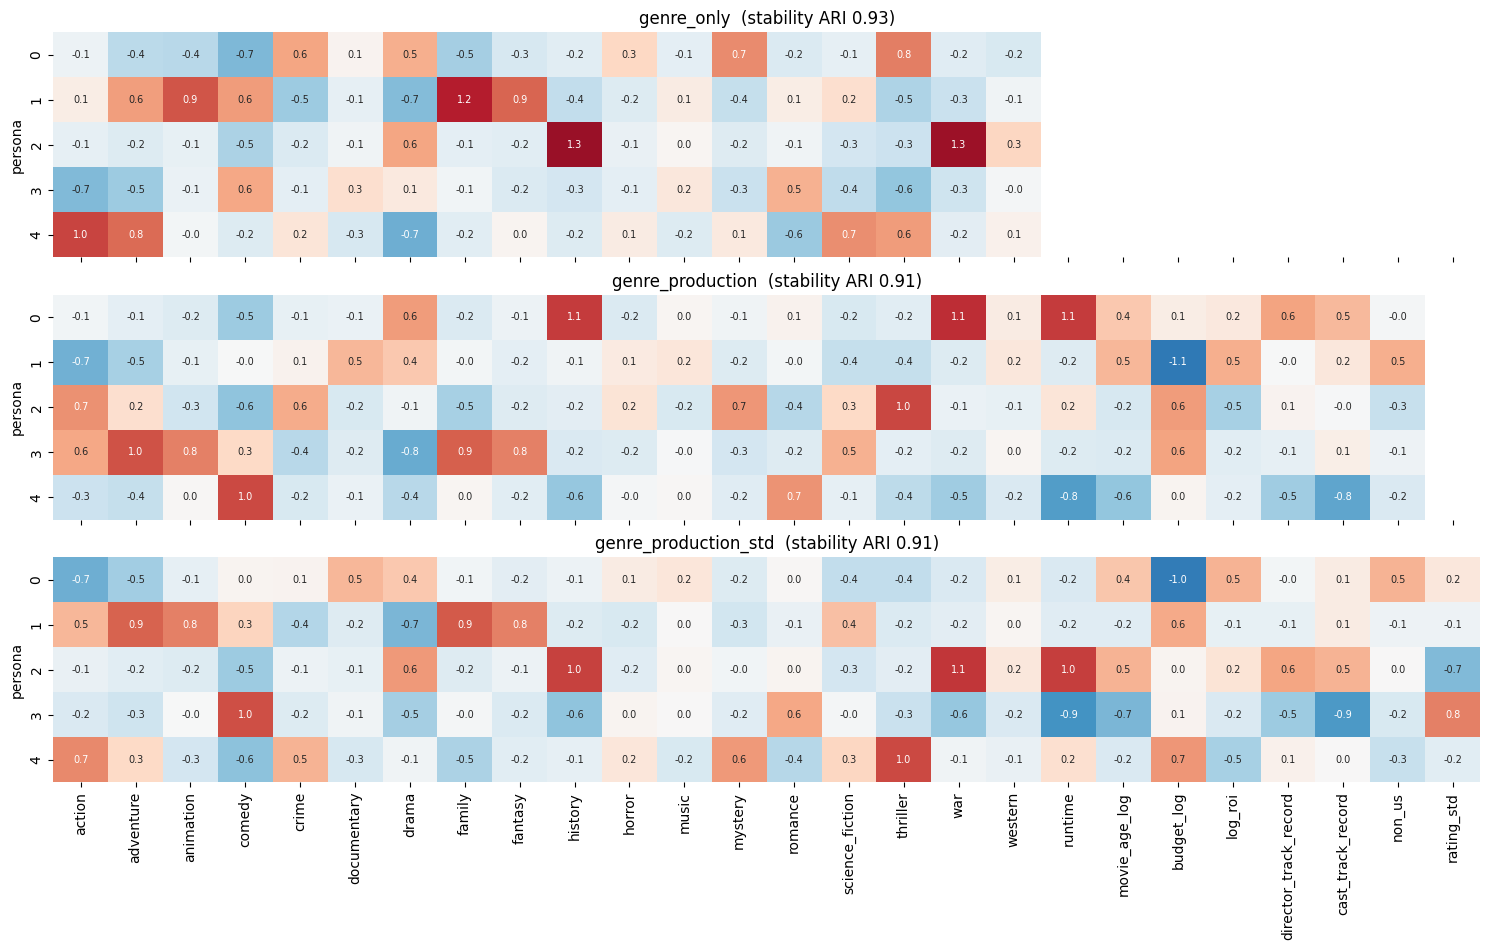

In [9]:
def persona_profile(name, labels):
    """Mean standardized taste per persona, on all PROFILE_COLS (NaN where the variant has no such column)."""
    cols = VARIANTS[name]
    z = pd.DataFrame(prep[name]["X"], index=profiles.index, columns=cols)
    return z.groupby(labels).mean().reindex(columns=PROFILE_COLS)


fig, axes = plt.subplots(len(VARIANTS), 1, figsize=(15, 3.2 * len(VARIANTS)), sharex=True)
for ax, (name, km) in zip(axes, fits.items()):
    sns.heatmap(persona_profile(name, km.labels_), cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5, annot=True, fmt=".1f",
                annot_kws={"fontsize": 7}, ax=ax, cbar=False, xticklabels=[c.removeprefix("genre_") for c in PROFILE_COLS])
    ax.set_title(f"{name}  (stability ARI {stab.loc[BEST_K, name]:.2f})")
    ax.set_ylabel("persona")
fig.tight_layout()
plt.show()

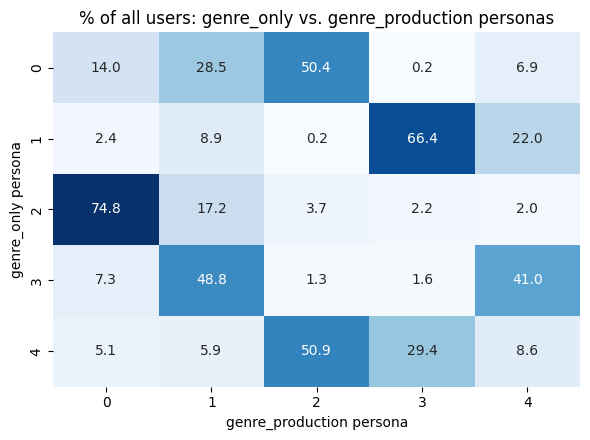

In [10]:
crosstab = pd.crosstab(
    pd.Series(fits["genre_only"].labels_, name="genre_only persona"),
    pd.Series(fits["genre_production"].labels_, name="genre_production persona"),
    normalize="index",
).mul(100)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(crosstab, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=ax)
ax.set_title("% of all users: genre_only vs. genre_production personas")
fig.tight_layout()
plt.show()

**What the three variants show.**

- **Silhouette does not rank the variants.** genre_only has the highest silhouette (0.063 vs. 0.058 / 0.057 at k = 5), but it also has the fewest features, and silhouette drops with the number of features by itself. Stability, which is comparable, is about the same for all three (0.93 / 0.91 / 0.91).
- **genre_only → genre_production: production features reorganize the personas.** Three personas carry over with the same genres and gain production traits:
  - history / war → *Classic epics*, which also like long films and well-rated directors and casts;
  - family / animation / fantasy → *Family & adventure*;
  - comedy / romance → *Light comedy & romance*, which also like short, recent films.

  The two action-related genre personas (thriller / crime / mystery and action / adventure / sci-fi) are redistributed: thriller and action merge, adventure and sci-fi join the family persona. This frees a place for a new persona, **Arthouse & international** (small budgets, non-US, older films, documentaries), defined mainly by production features and absent from genre_only. The cross-tabulation above shows which genre_only persona each user came from: personas that carry over sit on one dominant cell, and the new persona collects users from several genre_only personas. Many users move between personas (ARI 0.28), so the production features change the grouping itself, not only its description.
- **genre_production → + `rating_std`: polarization adds interpretation, not structure.** The personas stay almost the same (ARI 0.80) and stability does not improve. The `rating_std` column labels personas that already exist: *Classic epics* avoid polarizing films (−0.7) and *Light comedy & romance* seek them (+0.8), following the runtime / era / cast differences these personas already have.

**UMAP view** 

UMAP squeezes each variant's standardized profiles into 2 dimensions so the personas can be seen. It runs on the same 20k-user sample, and each point is coloured by its persona. UMAP keeps local neighbourhoods but distorts distances and density: gaps or islands in the picture are **not** evidence of separate groups. The personas are judged by stability and by the profiles above.

c:\Users\yael\anaconda3\envs\pythonProject\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yael\anaconda3\envs\pythonProject\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yael\anaconda3\envs\pythonProject\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


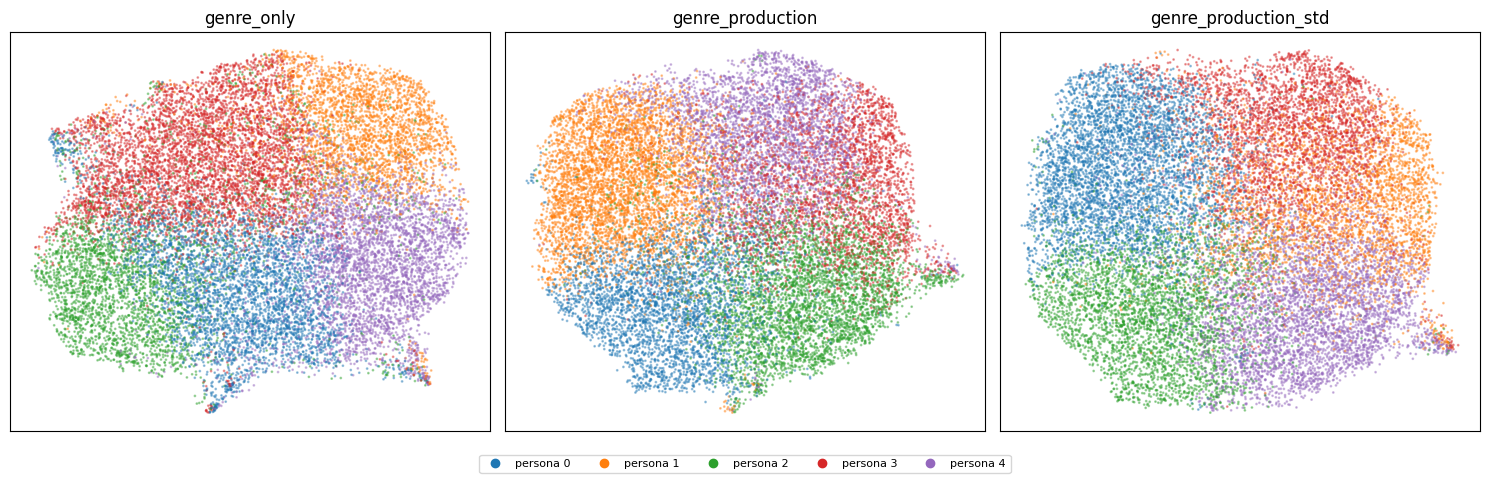

In [11]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(15, 4.8))
for ax, (name, km) in zip(axes, fits.items()):
    emb = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE).fit_transform(prep[name]["X"][sil_idx])
    ax.scatter(emb[:, 0], emb[:, 1], c=km.labels_[sil_idx], cmap="tab10", vmin=0, vmax=9, s=1, alpha=0.4)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
handles = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab10(k), label=f"persona {k}") for k in range(BEST_K)]
fig.legend(handles=handles, loc="lower center", ncol=BEST_K, fontsize=8)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

**Chosen variant.** The personas used from here on, and in `08`, come from `MAIN_VARIANT` (the reasons are in the observations at the end).

In [12]:
MAIN_VARIANT = "genre_production"

labels = fits[MAIN_VARIANT].labels_
pd.Series(labels).value_counts(normalize=True).sort_index().mul(100).round(1).rename("% users")

0    18.4
1    24.8
2    21.7
3    16.9
4    18.2
Name: % users, dtype: float64

## 5. Describing the personas

Each row is a persona, each column a profile feature, and the colour is the persona's average **standardized** profile value (0 = average user, +1 = one standard deviation more taste for that feature than the average user). Generosity statistics are shown separately to check that the personas are about taste, not about how many stars users give.

In [13]:
cols = VARIANTS[MAIN_VARIANT]
persona_z = persona_profile(MAIN_VARIANT, labels)[cols]
persona_z.index.name = "persona"

summary = pd.DataFrame({
    "% users": pd.Series(labels).value_counts(normalize=True).sort_index().mul(100).round(1).to_numpy(),
    "likes most": persona_z.apply(lambda r: ", ".join(r.nlargest(3).index.str.removeprefix("genre_")), axis=1),
    "likes least": persona_z.apply(lambda r: ", ".join(r.nsmallest(3).index.str.removeprefix("genre_")), axis=1),
}, index=persona_z.index)
generosity = user_stats.loc[profiles.index, ["user_mean", "user_std", "user_n"]].groupby(labels).mean()
summary.join(generosity.round(2))

,% users,likes most,likes least,user_mean,user_std,user_n
persona,,,,,,
0,18.4,"war, runtime, history","comedy, science_fiction, horror",3.60,0.94,99.62
1,24.8,"log_roi, non_us, movie_age_log","budget_log, action, adventure",3.54,1.02,118.16
2,21.7,"thriller, action, mystery","comedy, log_roi, family",3.68,0.96,97.76
3,16.9,"adventure, family, animation","drama, crime, mystery",3.69,0.96,102.13
4,18.2,"comedy, romance, budget_log","runtime, cast_track_record, movie_age_log",3.68,0.99,92.87


**Persona × genre scores** for the model: the average of `rating − user_mean` that each persona gives to each genre, over training movies (how much above or below their own average the persona rates the genre). In `08` a movie's `persona_genre_score` is the mean of these values over the movie's genres.

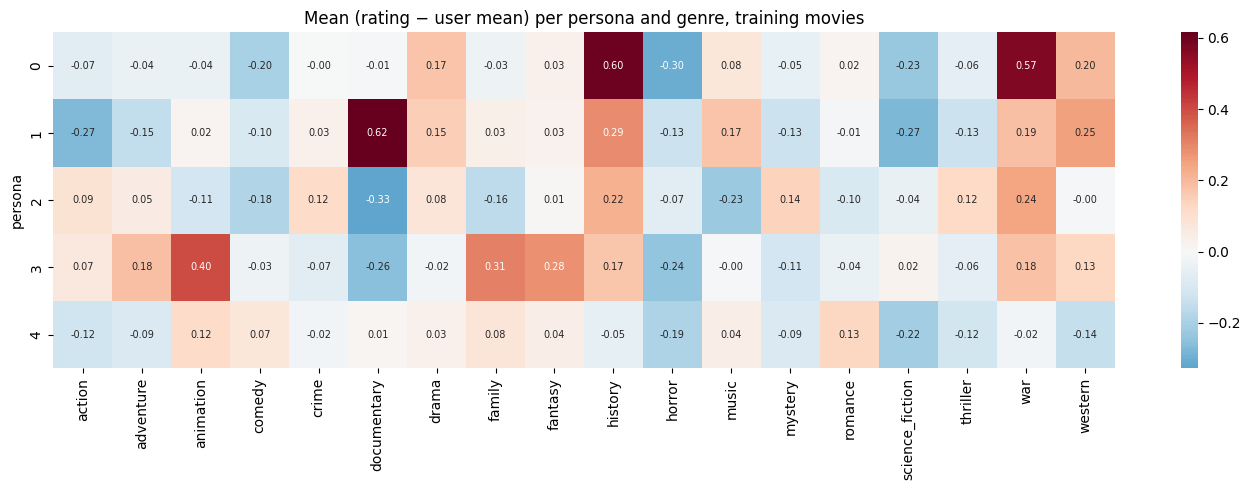

In [14]:
persona_of = pd.Series(labels, index=profiles.index)
r = ratings[ratings["rater_id"].isin(profiles.index)]
dev = r["rating"].to_numpy(dtype=float) - user_stats["user_mean"].reindex(r["rater_id"]).to_numpy()
persona = persona_of.reindex(r["rater_id"]).to_numpy()
genre_flags = train_movies[GENRE_COLS].reindex(r["netflix_movie_id"]).to_numpy()

persona_genre = pd.DataFrame({
    g.removeprefix("genre_"): pd.Series(dev[genre_flags[:, j] == 1]).groupby(persona[genre_flags[:, j] == 1]).mean()
    for j, g in enumerate(GENRE_COLS)
})
persona_genre.index.name = "persona"

fig, ax = plt.subplots(figsize=(14, 0.6 * BEST_K + 2))
sns.heatmap(persona_genre, cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"fontsize": 7}, ax=ax)
ax.set_title("Mean (rating − user mean) per persona and genre, training movies")
fig.tight_layout()
plt.show()

## 6. Save

- `user_personas.csv`: `rater_id`, `persona_id` (the chosen variant), and the distance to each persona centre (`dist_0…`) as soft membership features for the model.
- `user_profiles.csv`: the unscaled taste profiles on the chosen variant's features (model feature group C).
- `persona_genre_scores.csv`: persona × genre scores from above.

In [15]:
distances = fits[MAIN_VARIANT].transform(prep[MAIN_VARIANT]["X"])
user_personas = pd.DataFrame({"persona_id": labels}, index=profiles.index).join(
    pd.DataFrame(distances, index=profiles.index, columns=[f"dist_{i}" for i in range(BEST_K)])
)
main_profiles = profiles[VARIANTS[MAIN_VARIANT]]

user_personas.reset_index().to_csv(PROCESSED / "user_personas.csv", index=False)
main_profiles.reset_index().to_csv(PROCESSED / "user_profiles.csv", index=False)
persona_genre.reset_index().to_csv(PROCESSED / "persona_genre_scores.csv", index=False)
print(f"user_personas: {user_personas.shape} | user_profiles: {main_profiles.shape} | persona_genre_scores: {persona_genre.shape}")

user_personas: (332265, 6) | user_profiles: (332265, 25) | persona_genre_scores: (5, 18)


**Observations**

- **No natural clusters, but stable personas.** Silhouettes are low (0.03–0.09) and fall steadily with k in all three variants: user taste is a continuum, and the personas are a segmentation of it rather than separate groups (the UMAP view shows the same: one cloud, divided into coloured regions). They are nevertheless reproducible: fitting on two random halves of the users gives ARI ≥ 0.9 at k = 4–6 for genre_only and genre_production, while some larger k are unstable (k = 7 for genre_only: 0.51; k = 8 for genre_production: 0.53).
- **`BEST_K = 5`:** stable in all three variants (ARI 0.91–0.93), balanced (17–25% of users each), and every persona has a clear, distinct profile. Silhouette drops sharply after k = 6.
- **Production metadata adds to genres.** Clustering on genres alone and on genres + production give quite different groupings (ARI 0.28 between them), at almost the same stability (0.93 vs 0.91). The genre_production personas are defined by genre *and* production together: an *Arthouse & international* persona (small budgets, non-US, older films, documentaries) appears that genre_only cannot find, and *Classic epics* combine war / history with long runtimes and well-rated directors and casts. Budget scale, country and era are therefore real dimensions of user taste, not a repeat of the genre split.
- **Polarization taste does not improve the clustering.** Adding `rating_std` gives nearly the same personas (ARI 0.80 with genre_production) and no gain in stability (0.91 at k = 5; less stable at k = 6, 0.73 vs 0.91). `rating_std` does separate personas (*Classic epics* −0.7, *Light comedy & romance* +0.8), but only along a line the personas already have: polarizing taste goes together with shorter, newer films with less-known casts (profile correlations −0.35 with runtime, −0.36 with age, −0.28 with cast track record). It describes the personas but does not create new ones.
- **Chosen variant: genre_production** (genres + 7 production features, without `rating_std`).
- **The five personas** (from the profile heatmap and the persona × genre scores):

  | persona | name | likes (relative to own average) | dislikes |
  |---|---|---|---|
  | 0 | Classic epics | war, history, drama, long films, well-rated directors and casts | comedy, sci-fi, horror |
  | 1 | Arthouse & international | small budgets, non-US films, older films, documentaries, high ROI | action, adventure, big budgets |
  | 2 | Thrillers & action | thriller, action, mystery, crime, big budgets | comedy, family, low-ROI films |
  | 3 | Family & adventure | adventure, animation, family, fantasy | drama, crime, mystery |
  | 4 | Light comedy & romance | comedy, romance; short, recent films with less-known casts | history, war, long films |

- **Personas are about taste, not generosity:** average user mean ranges only 3.54–3.69 across personas, user std 0.94–1.02 and number of ratings 93–118.